In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [3]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,Location,Price,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,1,1360,5,4,3,Downtown,149919,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,4272,5,4,3,Downtown,424998,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,3592,2,2,3,Downtown,266746,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,966,4,2,2,Suburban,244020,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,4926,1,4,2,Downtown,636056,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,Suburban,295620,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,1997,3046,5,2,1,Suburban,580929,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,1998,1062,5,1,2,Rural,476925,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998,1999,4062,3,1,2,Urban,161119,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull()

,Id,Area,Bedrooms,Bathrooms,Floors,Location,Price,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1996,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1997,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1998,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [5]:
df.isnull().sum()

Id                0
Area              0
Bedrooms          0
Bathrooms         0
Floors            0
Location          0
Price             0
Unnamed: 7     2000
Unnamed: 8     2000
Unnamed: 9     2000
Unnamed: 10    2000
Unnamed: 11    2000
Unnamed: 12    2000
Unnamed: 13    2000
Unnamed: 14    2000
Unnamed: 15    2000
Unnamed: 16    2000
Unnamed: 17    2000
Unnamed: 18    2000
Unnamed: 19    2000
Unnamed: 20    1999
dtype: int64

In [6]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,Location,Price,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,1,1360,5,4,3,Downtown,149919,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,4272,5,4,3,Downtown,424998,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,3592,2,2,3,Downtown,266746,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,966,4,2,2,Suburban,244020,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,4926,1,4,2,Downtown,636056,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['Price']

0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64

In [8]:
df.shape

(2000, 21)

In [9]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,Price,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,537676.855000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
std,577.494589,1295.146799,1.424606,1.10899,0.809188,276428.845719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,501.000000,1.000000,1.00000,1.000000,50005.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,300098.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,539254.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,780086.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,999656.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


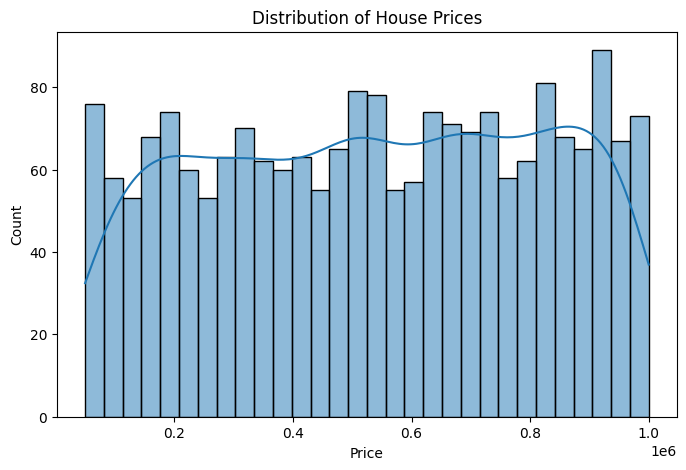

In [10]:
# Distribution of House Prices
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, bins=30)
plt.title("Distribution of House Prices")
plt.show()

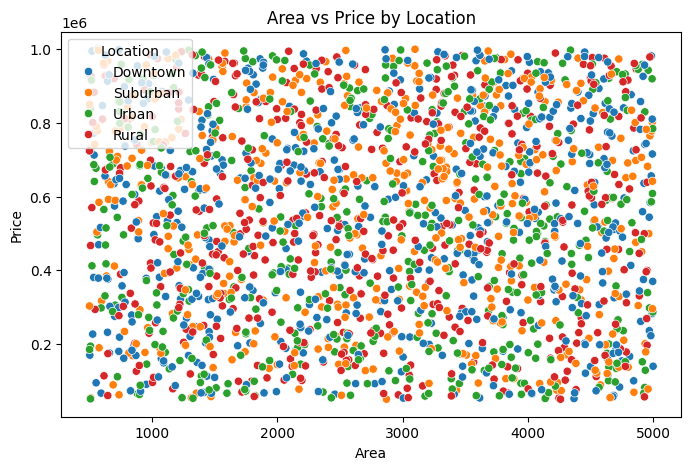

In [11]:
# Price vs Area (Scatterplot)
plt.figure(figsize=(8,5))
sns.scatterplot(x="Area", y="Price", hue="Location", data=df)
plt.title("Area vs Price by Location")
plt.show()

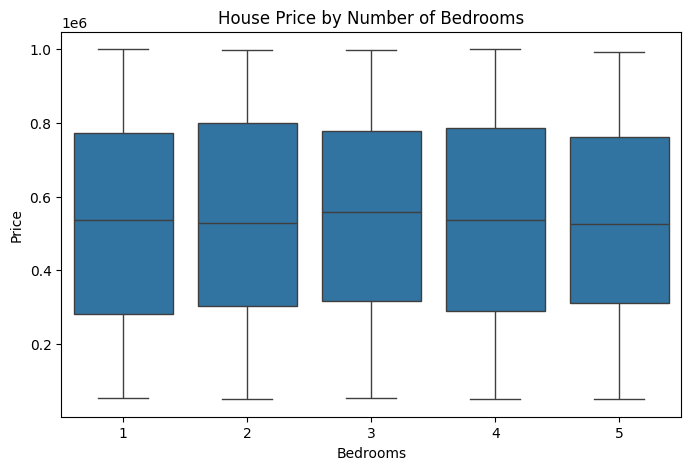

In [12]:
# Bedrooms vs Price (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x="Bedrooms", y="Price", data=df)
plt.title("House Price by Number of Bedrooms")
plt.show()

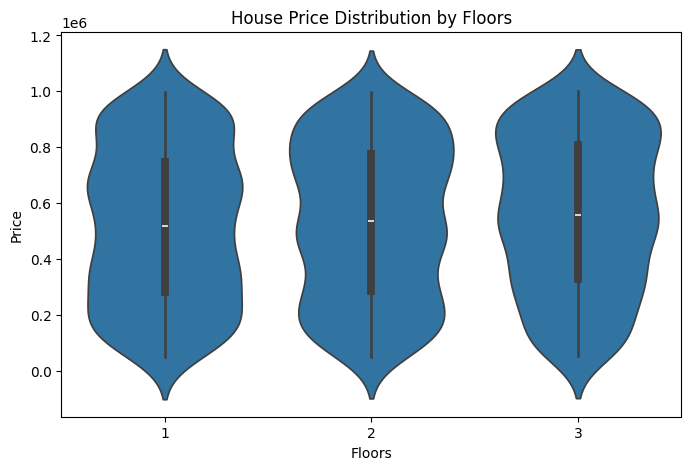

In [13]:
# Floors vs Price (Violinplot)
plt.figure(figsize=(8,5))
sns.violinplot(x="Floors", y="Price", data=df, inner="box")
plt.title("House Price Distribution by Floors")
plt.show()

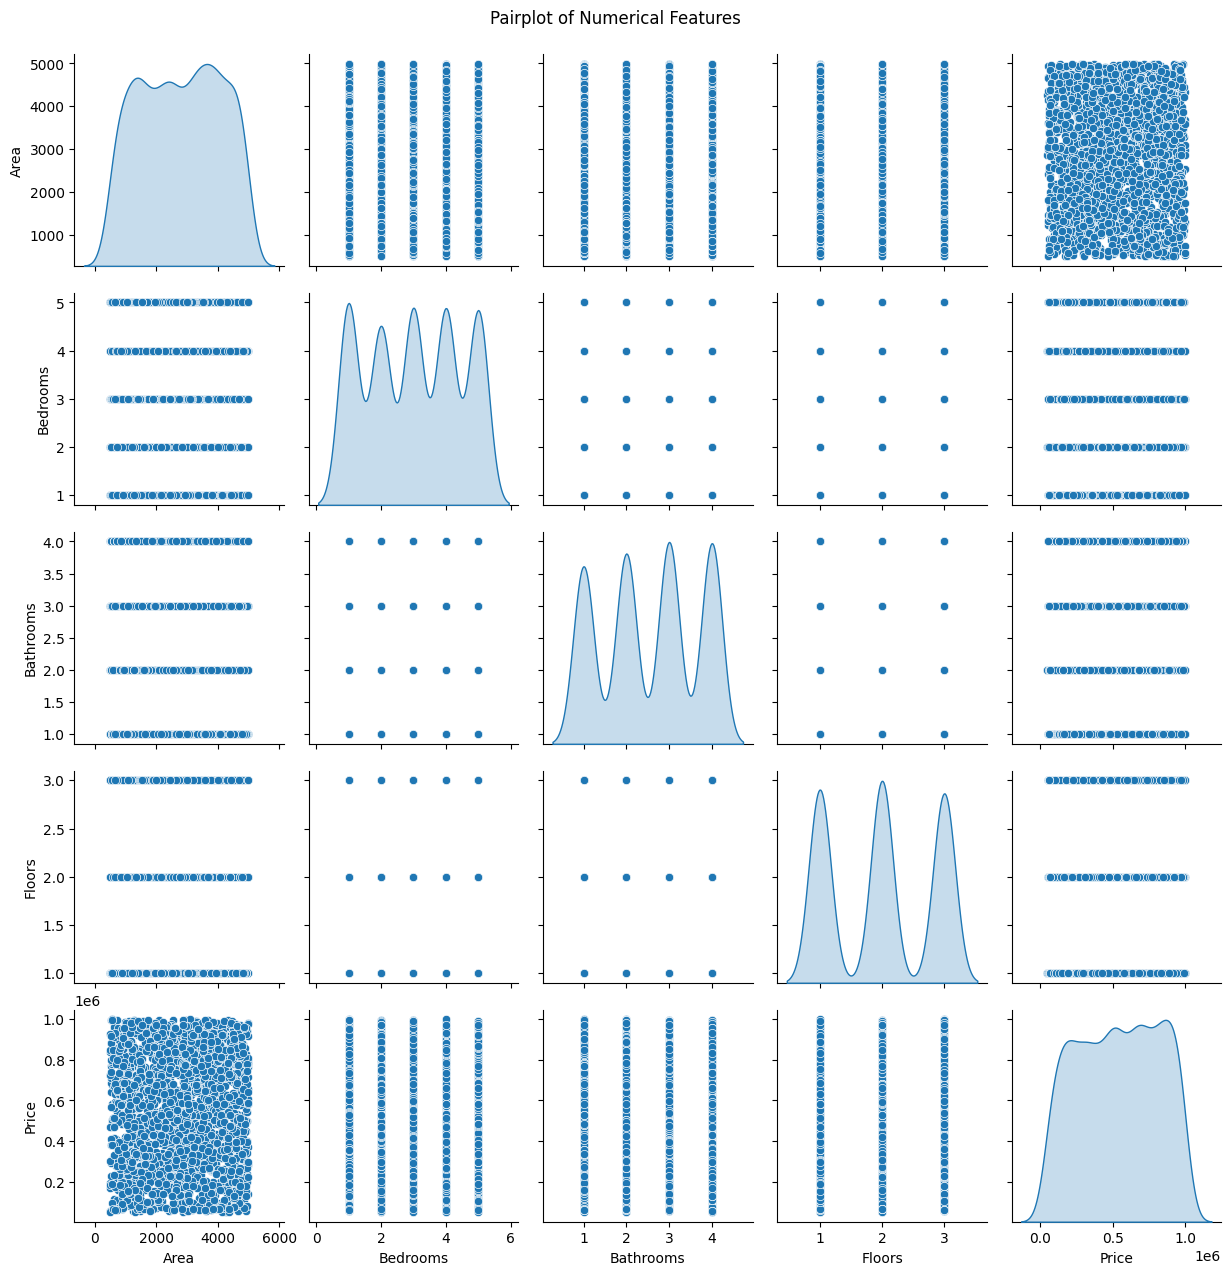

In [14]:
# Pairplot for numerical features
sns.pairplot(df[["Area", "Bedrooms", "Bathrooms", "Floors","Price"]], diag_kind="kde")
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

In [15]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

In [16]:
col = make_column_transformer((OneHotEncoder(sparse_output=False),['Location']),remainder='passthrough')

In [17]:
lr = LinearRegression()

In [18]:
scaler = StandardScaler()

In [19]:
model = make_pipeline(col,scaler,lr)

In [20]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Assuming you have a DataFrame 'df' with your data and target column 'Price'
# Define features and target
x = df[['Location', 'Area', 'Bedrooms', 'Bathrooms', 'Floors']]
y = df['Price']

# Separate categorical and numeric columns
categorical = ['Location']
numerical = ['Area', 'Bedrooms', 'Bathrooms', 'Floors']

# Transformers
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing locations
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # fill missing numbers with mean
])

# Split data into train and test sets (fix typo in random_state)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),
        ('num', numeric_transformer, numerical)
    ]
)

# Final pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit the model
model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
model.score(x_test, y_test)

0.0031634779154768866

In [22]:
Input_data = pd.DataFrame([{
        'Id' : 1,
        'Area' : 1360,
        'Bedrooms' : 5,
        'Bathrooms' : 4,
        'Floors' : 4,
        'YearBuilt': 1970,
        'Location' : 'Downtown',
}])

model.predict(Input_data)

array([547793.51281001])

In [23]:
import pickle as pk

In [24]:
pk.dump(model,open('House_prediction_model.pkl','wb'))